# Assignment 2: Neural Networks and Optimization (33 marks total)
### Due: October 3 at 11:59pm

### Name: Al Farhana Siddique (30157968)

### In this assignment, you will need to write code that uses a linear model and a neural network to perform a regression task. You will also be asked to describe the process by which you came up with the code. More details can be found below. Please cite any websites or AI tools that you used to help you with this assignment.

## Part 1: Linear Regression vs. Neural Network

For this assignment, we will be using the concrete example from yellowbrick. We will be evaluating how well neural networks perform compared to linear regression.

### Step 0: Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# %%capture
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn


In [7]:
import warnings
warnings.filterwarnings(action='ignore')

### Step 1: Data Input (2 marks)

The data used for this task can be imported using the yellowbrick library: 
https://www.scikit-yb.org/en/latest/api/datasets/concrete.html

Use the yellowbrick function `load_concrete()` to load the concrete dataset into the feature matrix `X` and target vector `y`.

*Note: the yellowbrick library is not included in the default Anaconda installation, so you will need to install it*

In [89]:
# TO DO: Import concrete dataset from yellowbrick library (0.5 marks)
import yellowbrick.datasets
# TO DO: Print size and type of X and y (0.5 marks)
from yellowbrick.datasets import load_concrete
# TO DO: Print size and type of X and y (0.5 marks)
X, y = load_concrete()
print("Type of X : ",type(X),"\nSize of X : ",X.size)
print("Type of y : ",type(y),"\nSize of y : ",y.size)


Type of X :  <class 'pandas.core.frame.DataFrame'> 
Size of X :  8240
Type of y :  <class 'pandas.core.series.Series'> 
Size of y :  1030


In [104]:
# TO DO: Inspect the first few columns of the imported feature matrix (0.5 marks)
X.head()

,cement,slag,ash,water,splast,coarse,fine,age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [97]:
# TO DO: Use .describe() to inspect the mean and variance of each feature (0.5 marks)
var = X.var().rename("variance")
X.describe().transpose().join(var)[['mean', 'variance']]

,mean,variance
cement,281.165631,10921.742654
slag,73.895485,7444.083725
ash,54.187136,4095.548093
water,181.566359,456.060245
splast,6.203112,35.682602
coarse,972.918592,6045.656228
fine,773.578883,6428.099159
age,45.662136,3990.437729


### Step 2: Data Processing (2 marks)

Check if there are any missing values and fill them in if necessary. Remove any non-numeric columns.

In [122]:
# TO DO: Process the data - fill-in any missing values and remove any non-numeric columns (0.5 marks)
median = X.median() 
X = X.fillna(median) 
X = X.select_dtypes(include=["number"])
#remove print after comparing with anfaals code
print(X)

      cement   slag    ash  water  splast  coarse   fine  age
0      540.0    0.0    0.0  162.0     2.5  1040.0  676.0   28
1      540.0    0.0    0.0  162.0     2.5  1055.0  676.0   28
2      332.5  142.5    0.0  228.0     0.0   932.0  594.0  270
3      332.5  142.5    0.0  228.0     0.0   932.0  594.0  365
4      198.6  132.4    0.0  192.0     0.0   978.4  825.5  360
...      ...    ...    ...    ...     ...     ...    ...  ...
1025   276.4  116.0   90.3  179.6     8.9   870.1  768.3   28
1026   322.2    0.0  115.6  196.0    10.4   817.9  813.4   28
1027   148.5  139.4  108.6  192.7     6.1   892.4  780.0   28
1028   159.1  186.7    0.0  175.6    11.3   989.6  788.9   28
1029   260.9  100.5   78.3  200.6     8.6   864.5  761.5   28

[1030 rows x 8 columns]


You can add the target vector and the feature matrix together and inspect the relationship between the features and target using a `pairplot()`

In [128]:
# TO DO: Add the target vector and the feature matrix together (0.5 marks)
X_y = X.copy()
X_y = X_y.join(y)

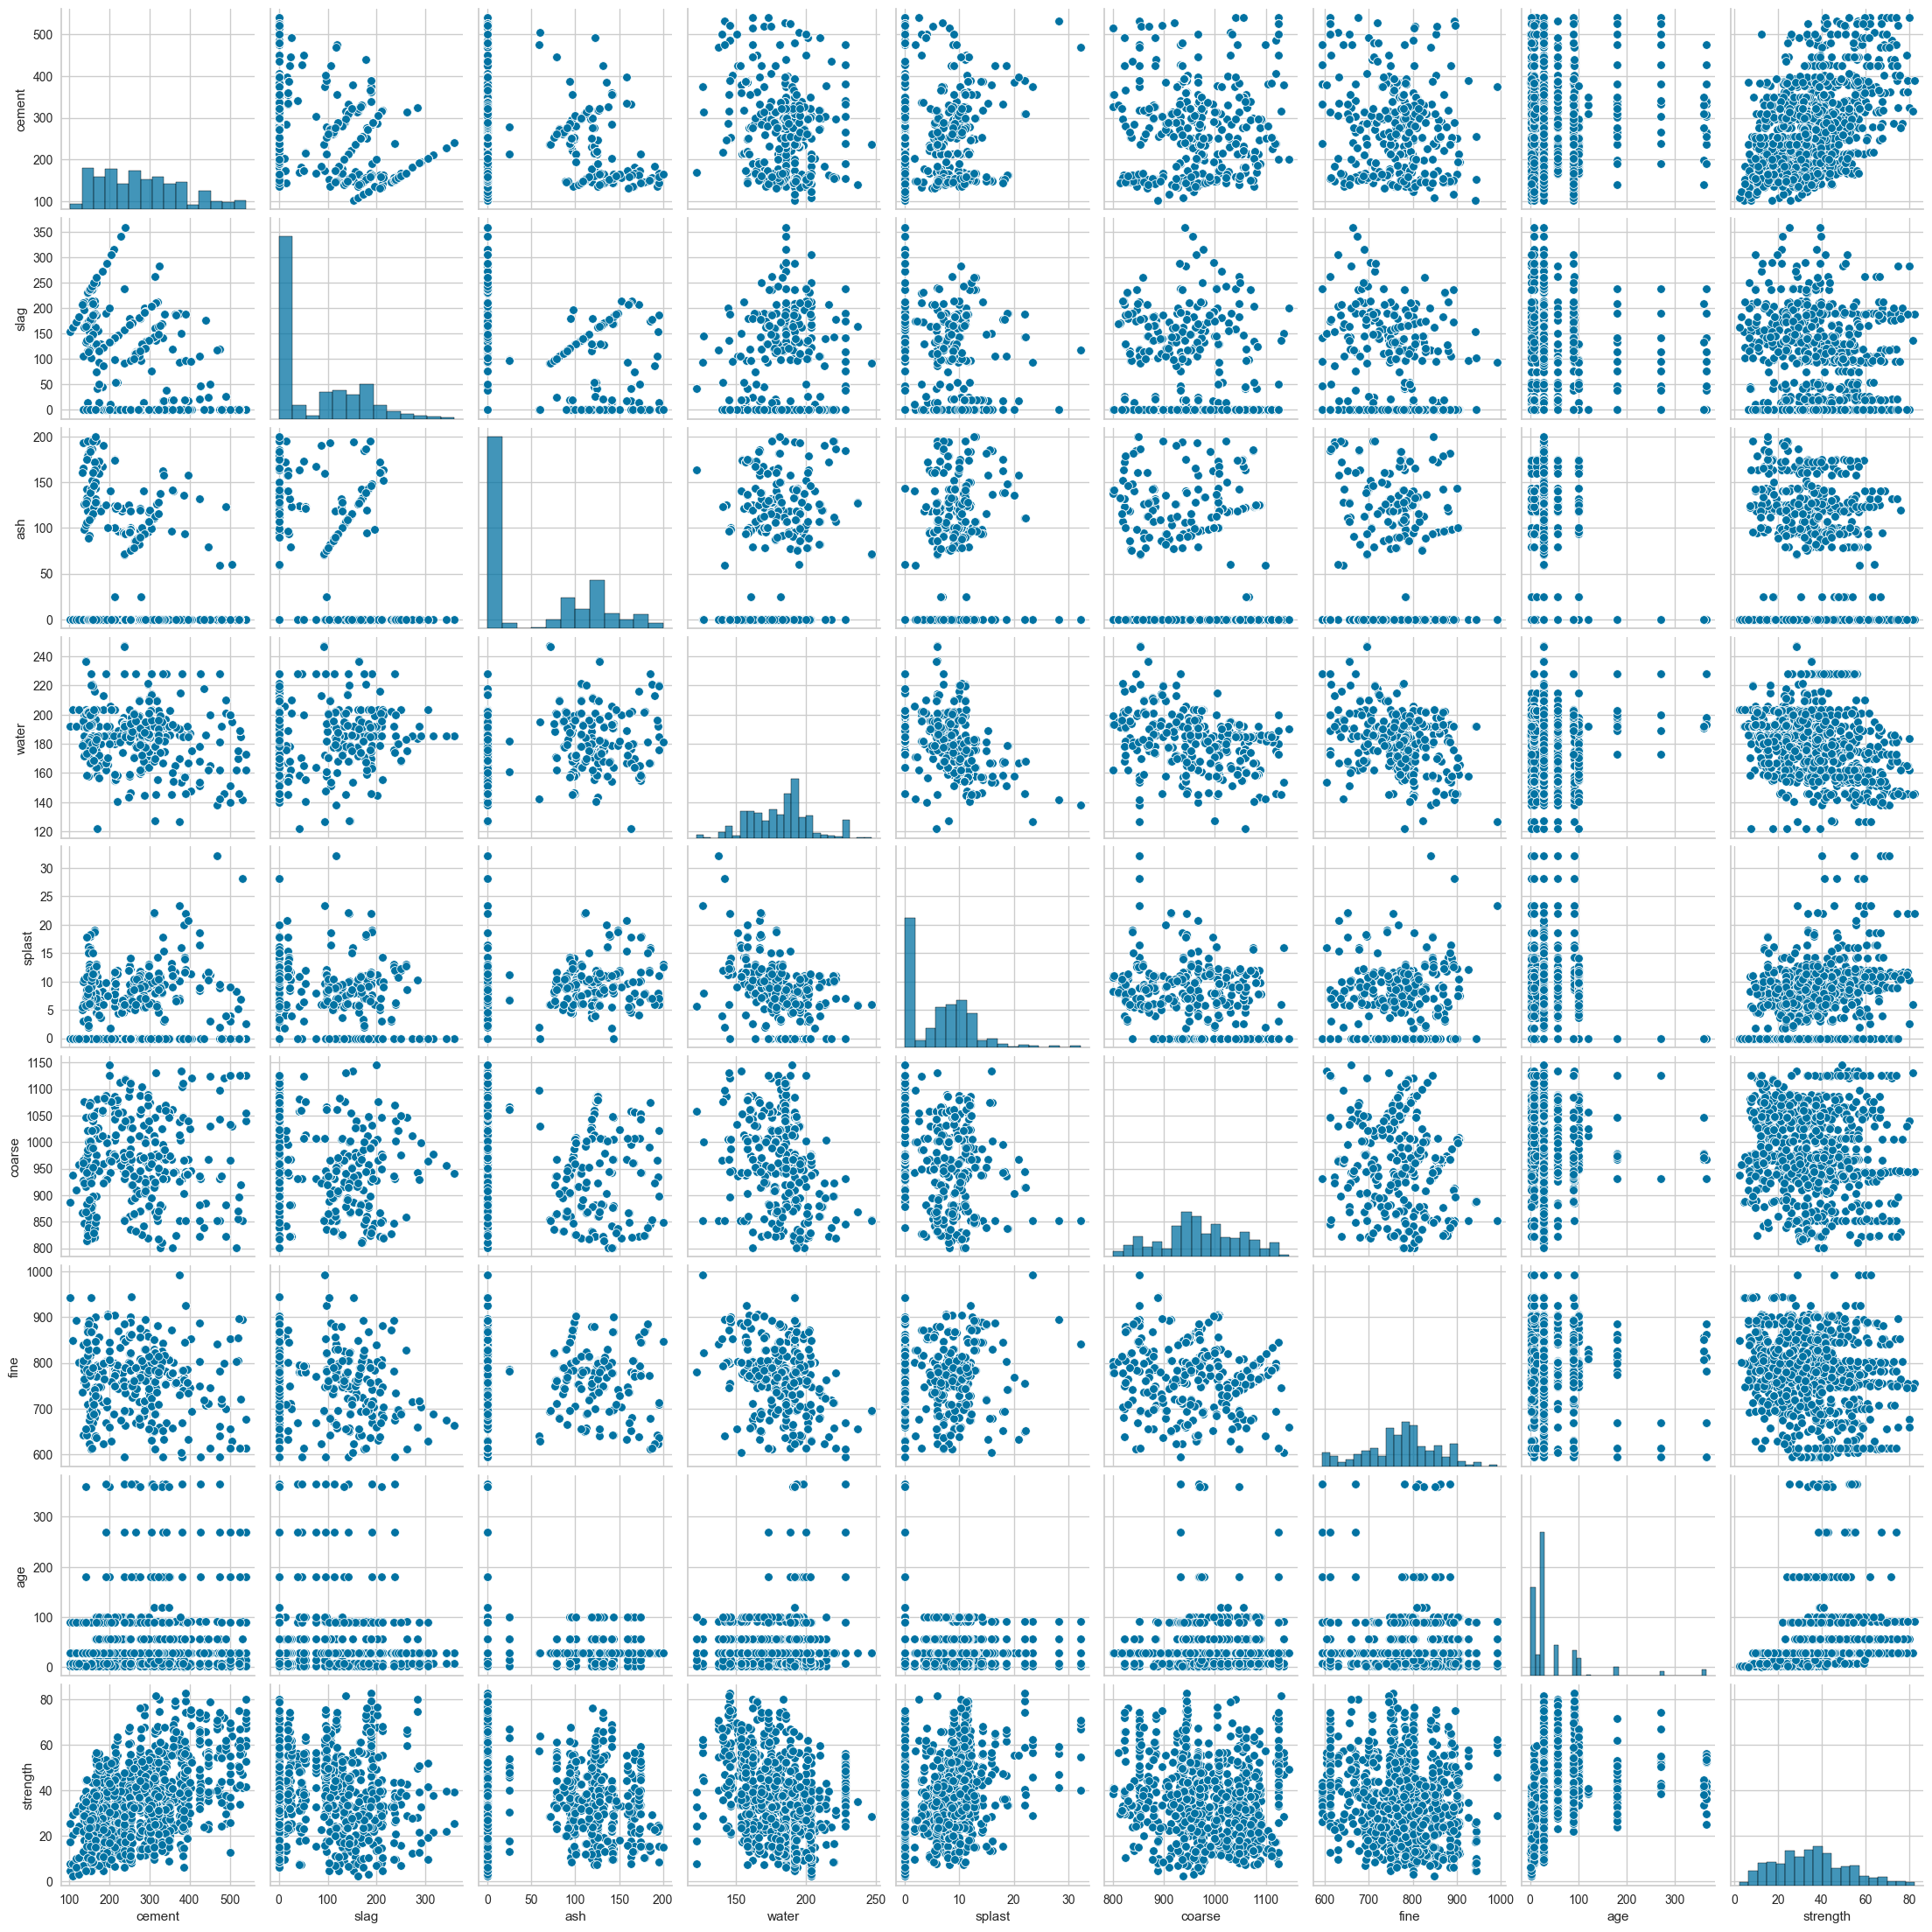

In [126]:
# TO DO: Use pairplot() (0.5 marks)
sns.pairplot(X_y)

The concrete data is already be split into the feature matrix and target vector. The next step is to split the data into training and testing subsets. For this assignment, you can use `train_test_split()` with `random_state=0`

In [205]:
# TO DO: Split the data into training and testing data (0.5 marks)
from sklearn.model_selection import train_test_split
train_X, test_X,train_y, test_y  = train_test_split(X,y,test_size=0.2,random_state= 0)


Looking at the mean and variance of the dataset, it is clear that the features have a wide range of values. You can use the code below to scale the feature matrix

*Note: `StandardScaler()` scales the data to a mean of 0 and a variance of 1*

In [206]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_X)
test_scaled = scaler.transform(test_X)

### Step 3: Implement Machine Learning Model (2 marks)

1. Import `LinearRegression` from sklearn
2. Instantiate model `LinearRegression()`
3. Implement the machine learning model with the scaled data

In [207]:
# TO DO: ADD YOUR CODE HERE
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(train_scaled, train_y)
tr_y_predict = lr.predict(train_scaled)
tst_y_predict = lr.predict(test_scaled)

### Step 4: Validate Model (3 marks)

Calculate the training and validation accuracy using mean squared error.

In [208]:
# TO DO: ADD YOUR CODE HERE (2 marks)
from sklearn.metrics import mean_squared_error
mean_test = mean_squared_error(test_y,tst_y_predict)
mean_train = mean_squared_error(train_y,tr_y_predict)

In [209]:
# TO DO: Print the results (1 mark)
print(mean_test)
print(mean_train)


95.6353348269043
110.34550122934108


## Part B: Neural Network

Now we will repeat the above analysis using a neural network. For this assignment, we will be using the PyTorch library.

In [210]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

### Step 2: Data Processing (2 marks)

To make this analysis easier, we can convert the data into tensors.

In [211]:
# TO DO: Convert training and testing data to tensors (1 mark)
tr_X_tensor = torch.tensor(train_scaled,dtype=torch.float32)
tst_X_tensor = torch.tensor(test_scaled,dtype=torch.float32)

tr_y_tensor = torch.tensor(train_y.values,dtype=torch.float32)
tst_y_tensor = torch.tensor(test_y.values,dtype=torch.float32)


In [212]:
# TO DO: Print the size of the training features and labels (1 mark)
print(tr_X_tensor.size())
print(tr_y_tensor.size())



torch.Size([824, 8])
torch.Size([824])


The labels must be changed from a vector to a 2-D array to make sure that the math works properly. Use the provided code below to fix this issue:

In [213]:
y_train_tensor = tr_y_tensor.unsqueeze(1)
y_test_tensor = tst_y_tensor.unsqueeze(1)
print(y_train_tensor.size())

torch.Size([824, 1])


### Step 3: Implement Neural Network (10 marks)

For this assignment, we will use the SGD optimizer with the following parameters:
- Initial learning rate = 0.001
- Momentum = 0.9

We will use the same learning rate schedule that was used in the Backpropagation Example on D2L.

For the optimization process, we will need to both train and test the data for each epoch. It is up to you how you want to organize your code for this process. You will need to include the following steps:
- Load your data using the `DataLoader()`
- Define a model with two hidden layers with 50 hidden units each
- Choose your loss function
- initialize your optimizer
- Set up your training and testing loops for 100 epochs
    - Remember that you must go through the training and testing code for each epoch sequentially
- Print out the average training and testing loss for each epoch (or plot in graph)

In [228]:
from torch.optim.lr_scheduler import StepLR
# TO DO: ADD YOUR CODE HERE
tr_dst = TensorDataset(tr_X_tensor, tr_y_tensor)
tst_dst = TensorDataset(tst_X_tensor, tst_y_tensor)
batch_size = 32

# use the datasets you just created
tr_dl = DataLoader(tr_dst, batch_size=batch_size, shuffle=True)
tst_dl = DataLoader(tst_dst, batch_size=batch_size, shuffle=False)

# define input size, hidden layer size, output size
D_i = tr_X_tensor.shape[1]   # infer input size from data
D_k, D_o = 50, 1
# create model with two hidden layers
model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o))

# Initialization of weights
# If you don't do this, initial values will be chosen randomly
def weights_init(layer_in):
    if isinstance(layer_in, nn.Linear):
        nn.init.kaiming_normal_(layer_in.weight)
        layer_in.bias.data.fill_(0.0)
model.apply(weights_init)

# choose least squares loss function
criterion = nn.MSELoss()
# construct SGD optimizer and initialize learning rate and momentum
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001, momentum=0.9)
# object that decreases learning rate by half every 10 epochs
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

# loop over the dataset 100 times
for epoch in range(100):
    model.train()
    epoch_loss = 0.0
    # loop over batches
    for i, data in enumerate(tr_dl):
        # retrieve inputs and labels for this batch
        x_batch, y_batch = data
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward pass
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        # backward pass
        loss.backward()
        # SGD update
        optimizer.step()
        # update statistics
        epoch_loss += loss.item() * len(y_batch)      # accumulated error weighted by batch size
    # print error - the error for each epoch is the average over all the batches
    avg_train_loss = epoch_loss / len(tr_dst)         # average over all samples

    model.eval()
    test_loss_sum, test_count = 0.0, 0
    with torch.no_grad():
        for xb, yb in tst_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            test_loss_sum += loss.item() * yb.size(0)
            test_count += yb.size(0)
    avg_test_loss = test_loss_sum / test_count
    
    print(f"Epoch {epoch:3d} | Train MSE: {avg_train_loss:.4f} | Test MSE: {avg_test_loss:.4f}")
    # tell scheduler to consider updating learning rate
    scheduler.step()


Epoch   0 | Train MSE: 638.1877 | Test MSE: 347.6615
Epoch   1 | Train MSE: 336.3362 | Test MSE: 309.0788
Epoch   2 | Train MSE: 329.8780 | Test MSE: 285.3399
Epoch   3 | Train MSE: 303.4034 | Test MSE: 293.5791
Epoch   4 | Train MSE: 305.2384 | Test MSE: 266.4284
Epoch   5 | Train MSE: 301.9690 | Test MSE: 273.4069
Epoch   6 | Train MSE: 314.1636 | Test MSE: 273.2980
Epoch   7 | Train MSE: 297.0247 | Test MSE: 299.1389
Epoch   8 | Train MSE: 295.5849 | Test MSE: 264.8019
Epoch   9 | Train MSE: 298.6822 | Test MSE: 276.4742
Epoch  10 | Train MSE: 291.6428 | Test MSE: 264.4158
Epoch  11 | Train MSE: 284.5622 | Test MSE: 265.9409
Epoch  12 | Train MSE: 287.7759 | Test MSE: 273.2161
Epoch  13 | Train MSE: 283.8596 | Test MSE: 263.2298
Epoch  14 | Train MSE: 287.1627 | Test MSE: 264.1718
Epoch  15 | Train MSE: 283.1029 | Test MSE: 264.3294
Epoch  16 | Train MSE: 283.0891 | Test MSE: 264.3948
Epoch  17 | Train MSE: 284.6006 | Test MSE: 263.4910
Epoch  18 | Train MSE: 284.4733 | Test MSE: 27

### Questions (6 marks)
1. How did the results from the linear model compare to the results from the neural network? Why do you think one performed better than the other?
since neural network can adapt and train on the data it will give a better outcome than linear model
1. If you run the optimization/backpropagation code multiple times, you will see that you get different loss values. Why is this?
it will train on the data and give a better outcome if y9ou riun it again 
1. Compare the results from SGD to using Adam with default parameters and a constant learning rate of 0.01. Which model would you select to use and why?

*ANSWER HERE*


### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*

1. Where I sourced my code
I built my solution by combining provided materials on D2L with small utility snippets I wrote myself and a few clarifications from a generative AI assistant.
I followed the guidance in “Neural network tools.pdf” (D2L) to decide which libraries to import, how to fix version mismatches etc.
I referenced “Advertising example.ipynb” (D2L) to copy the pattern of reading a dataset, printing the first few rows, and summarizing columns before modeling.
I used “TF Regression.ipynb” (D2L) to structure the linear regression baseline and to remind myself that “standard deviation squared equals variance,” which I relied on when checking feature scaling and dispersion.
I again used “TF Regression.ipynb” (D2L) to structure the sequence of splitting data, fitting a simple linear model, and computing MSE on training and testing sets.
I adapted the “Advertising example.ipynb” (D2L) pattern for using StandardScaler, fitting on the training split, and transforming both splits consistently.
I also used a generative AI assistant (ChatGPT) for targeted clarifications, described below.

2. The order in which I completed the steps
Set up the environment and imports (from “Neural network tools.pdf”), then confirmed versions and that required packages import correctly.
Sketched the end-to-end flow by reading the “Advertising example.ipynb,” which helped me decide the order: load -> inspect  -> split  -> scale  ->  baseline model  -> metrics  -> neural network  -> comparison.
Loaded the assignment dataset and performed basic exploratory checks (head of the table, descriptive statistics, and data types).
Split the data into training and testing partitions and scaled features using StandardScaler, fitting the scaler only on the training data.
Implemented a linear regression baseline following “TF Regression.ipynb,” and computed MSE on both splits to establish a reference point.
Converted the data to tensors and prepared TensorDataset and DataLoader objects for the neural network portion (the general structure mirrored the D2L regression notebook’s flow).
Defined the NN (two hidden layers with Rectified Linear Unit activations), loss function (MSE), and optimizer (SGD with momentum).
Trained the NN for a fixed number of epochs while tracking training and testing losses each epoch.
Compared performance of the NN to the linear regression baseline and discussed differences.

3. Generative AI usage and how I modified the code
I used ChatGPT selectively to unblock myself and to avoid common shape and data-type mistakes when moving from pandas to tensors and setting up data loaders. My prompts were focused, and I verified all suggestions against the D2L notebooks.
Representative prompts I used:
	“Convert a pandas Series target y into a two-dimensional PyTorch tensor of shape (n, 1) without losing alignment with X.”
	“Create a minimal TensorDataset and DataLoader for regression with features X and target y; show batch shape expectations.”
	“Explain the order of operations for StandardScaler with a train–test split so that there is no data leakage.”
	“Why does the neural network expect a two-dimensional target for mean squared error, and how do I reshape correctly?”
Modifications I made after using AI:
I adjusted the target shaping to ensure it was a column vector (n, 1) rather than (n,), because the mean squared error expects matching shapes.
	I removed any unnecessary device or accelerator code to match the assignment’s environment.
	I ensured that the scaler was fit only on the training data and then applied to both sets, as emphasized in the D2L examples.
	I simplified the training loop to keep it consistent with the D2L structure (define, train, evaluate), retaining only the elements required by the rubric.
	
4. Challenges I faced and what helped me succeed
Data shape mismatches: Moving from a pandas Series to tensors caused an initial mismatch between (n,) and (n, 1). Reading the D2L regression notebook and asking a targeted AI prompt helped me reshape consistently and verify batch dimensions.
Version and import friction: The “Neural network tools.pdf” helped me verify that my local versions of the libraries were acceptable for the assignment and showed me how to test imports early so issues did not appear mid-training.
Maintaining a clean pipeline without data leakage: The “Advertising example.ipynb” reinforced the correct order: fit the scaler on the training split only, then transform both training and testing sets. Sticking to that order kept my evaluation meaningful
Keeping the neural network comparable to the baseline: Using the “TF Regression.ipynb” flow ensured my neural network results were directly comparable to the linear regression baseline by using the same splits, consistent scaling, and the same loss metric (mean squared error).


## Part 2: Reflection (2 marks)
Include a sentence or two about:
- what you liked or disliked,
- found interesting, confusing, challenging, motivating
while working on this assignment.


*ADD YOUR THOUGHTS HERE*

I liked seeing the full pipeline come together—load, split, scale, baseline, then the neural net—and watching the loss curves actually reflect the choices I made. What I did not like was how “black box” the network felt at times; without visuals, it sometimes felt like turning knobs and hoping. The most confusing bit was getting tensor shapes right and avoiding those quiet broadcasting mistakes, but once that clicked it was pretty satisfying. Overall it was motivating to see the neural net beat the linear model and to realize that small, disciplined steps in preprocessing and evaluation really matter.